## Fig 3: reinterpretation effect

Plots the LMER outputs from `005._subject_by_node_Viewing1_Viewing2_network_reinterpretation.Rmd`
as (1) a parcel-wise cortical surface map and (2) a 17-network effect distribution.

In [1]:
import os
import sys

import numpy as np
import pandas as pd
import matplotlib as mpl

from brainspace.datasets import load_parcellation
from neuromaps.datasets import fetch_fslr

sys.path.append('../utils/')
from plotting_brains_surfplot import map_values_to_atlas, Plot
from plotting_network_plots import (
    compare_network_effects,
    plot_17N_effect_distribution_horizontal,
)

mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['Helvetica Neue']
mpl.rcParams['font.size'] = 14

MODEL_OUTPUTS = 'model_outputs'
RESULTS_DIR = '../../results/reinterpretation_plots/'

/Users/f004p59/.local/lib/python3.7/site-packages/nilearn/__init__.py:67: FutureWarning: Python 3.7 support is deprecated and will be removed in release 0.12 of Nilearn. Consider switching to Python 3.9 or 3.10.
  _python_deprecation_warnings()


In [2]:
surfaces = fetch_fslr()
lh, rh = surfaces['inflated']
atlas_surf = load_parcellation('schaefer', 100, join=True)

### Loading in the data from the R models to plot

In [11]:
all_sub = pd.read_csv(os.path.join(
    MODEL_OUTPUTS, 'across_node_estimate_p_reinterpretation_neural_shift_poly_semantic_distance_3__reinterpretation.csv'))
network_values_17N = pd.read_csv(os.path.join(MODEL_OUTPUTS,'across_network_estimate_p_reinterpretation_neural_shift_poly_semantic_distance_3__17N.csv'))

column = 'neural_shift_poly_semantic_distance_3_1' #going to extract the linear fit one!
all_sub.head()

,node,_Intercept__estimate,_Intercept__p_value,neural_shift_estimate,neural_shift_p_value,poly_semantic_distance_3_1_estimate,poly_semantic_distance_3_1_p_value,poly_semantic_distance_3_2_estimate,poly_semantic_distance_3_2_p_value,poly_semantic_distance_3_3_estimate,poly_semantic_distance_3_3_p_value,neural_shift_poly_semantic_distance_3_1_estimate,neural_shift_poly_semantic_distance_3_1_p_value,neural_shift_poly_semantic_distance_3_2_estimate,neural_shift_poly_semantic_distance_3_2_p_value,neural_shift_poly_semantic_distance_3_3_estimate,neural_shift_poly_semantic_distance_3_3_p_value
0,1,0.556548,5.352130e-56,-0.007525,0.757645,-0.822697,0.434626,1.137491,0.286515,1.524813,0.185584,-0.625151,0.529684,-0.511235,0.614163,-1.440806,0.177602
1,2,0.525268,4.431534e-51,0.028112,0.034770,-1.802786,0.001230,0.850188,0.126967,1.774213,0.002133,0.456241,0.395514,-0.261906,0.632082,-1.901208,0.000456
2,3,0.533404,3.583608e-56,0.017673,0.341352,-1.157610,0.124182,0.737875,0.328435,1.028826,0.208605,-0.340563,0.663749,-0.149572,0.850526,-1.113299,0.184193
3,4,0.543689,5.333683e-56,0.005277,0.734410,-2.183156,0.000775,0.544339,0.401068,0.379199,0.581289,0.770292,0.215009,0.032506,0.959525,-0.415451,0.542817
4,5,0.545779,6.336650e-56,0.002948,0.856707,-1.856657,0.005216,0.320720,0.627634,0.811607,0.251900,0.455316,0.497554,0.301331,0.659440,-0.917544,0.206210


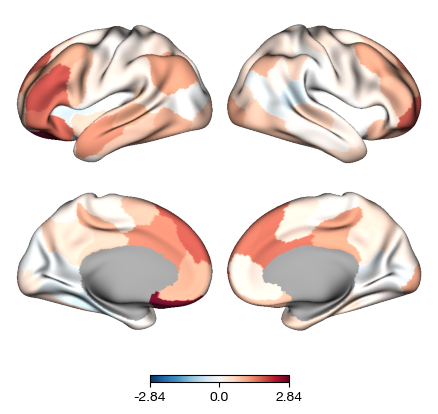

In [10]:
vals = all_sub[f'{column}_estimate'].to_numpy()
lim = np.max(np.abs(vals))

p = Plot(lh, rh, views=['lateral', 'medial'])
p.add_layer(map_values_to_atlas(atlas_surf, vals), cbar=True, cmap='RdBu_r',
            color_range=(-lim, lim), zero_transparent=False)

fig = p.build()
fig.savefig(os.path.join(RESULTS_DIR, f'surf_{column}.png'), dpi=300, transparent=True)

['DAN-A' 'DAN-B' 'DMN-A' 'DMN-B' 'DMN-C' 'FPN-A' 'FPN-B' 'FPN-C' 'LimbicA'
 'LimbicB' 'SomMotA' 'SomMotB' 'TempPar' 'VAN-A' 'VAN-B' 'VisCent'
 'VisPeri']
renamed them!

Creating horizontal 17N distribution plot for: neural_shift_poly_semantic_distance_3_1
Mode: Bar graph only
Sorting by network family grouping


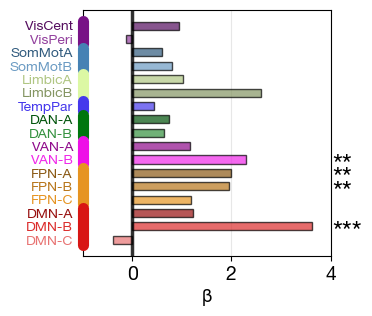


=== neural_shift_poly_semantic_distance_3_1 Summary (17N) ===

VisCent:
  Network Beta: 0.9424 
  q-value: 2.0112e-01
  Node count: 7
  Node mean: 0.4953
  Node median: 0.4562
  Node std: 0.3707
  Node range: [-0.0538, 1.0885]

VisPeri:
  Network Beta: -0.1309 
  q-value: 8.3953e-01
  Node count: 6
  Node mean: -0.0611
  Node median: -0.1157
  Node std: 0.2134
  Node range: [-0.3406, 0.2881]

SomMotA:
  Network Beta: 0.6005 
  q-value: 3.0105e-01
  Node count: 6
  Node mean: 0.2513
  Node median: 0.2363
  Node std: 0.1245
  Node range: [0.1167, 0.4733]

SomMotB:
  Network Beta: 0.7969 
  q-value: 2.3348e-01
  Node count: 8
  Node mean: 0.1943
  Node median: 0.1010
  Node std: 0.2429
  Node range: [-0.0184, 0.7108]

LimbicA:
  Network Beta: 1.0283 
  q-value: 3.9110e-01
  Node count: 3
  Node mean: 0.5186
  Node median: 0.6055
  Node std: 0.3100
  Node range: [0.1745, 0.7759]

LimbicB:
  Network Beta: 2.5997 
  q-value: 6.1616e-02
  Node count: 2
  Node mean: 1.8722
  Node median: 1.87

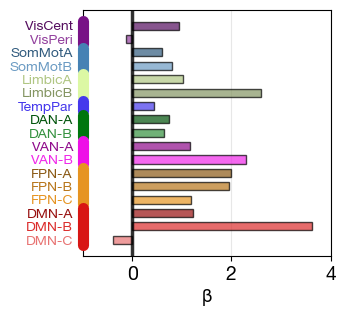


=== neural_shift_poly_semantic_distance_3_1 Summary (17N) ===

VisCent:
  Network Beta: 0.9424 
  q-value: 2.0112e-01
  Node count: 7
  Node mean: 0.4953
  Node median: 0.4562
  Node std: 0.3707
  Node range: [-0.0538, 1.0885]

VisPeri:
  Network Beta: -0.1309 
  q-value: 8.3953e-01
  Node count: 6
  Node mean: -0.0611
  Node median: -0.1157
  Node std: 0.2134
  Node range: [-0.3406, 0.2881]

SomMotA:
  Network Beta: 0.6005 
  q-value: 3.0105e-01
  Node count: 6
  Node mean: 0.2513
  Node median: 0.2363
  Node std: 0.1245
  Node range: [0.1167, 0.4733]

SomMotB:
  Network Beta: 0.7969 
  q-value: 2.3348e-01
  Node count: 8
  Node mean: 0.1943
  Node median: 0.1010
  Node std: 0.2429
  Node range: [-0.0184, 0.7108]

LimbicA:
  Network Beta: 1.0283 
  q-value: 3.9110e-01
  Node count: 3
  Node mean: 0.5186
  Node median: 0.6055
  Node std: 0.3100
  Node range: [0.1745, 0.7759]

LimbicB:
  Network Beta: 2.5997 
  q-value: 6.1616e-02
  Node count: 2
  Node mean: 1.8722
  Node median: 1.87

In [12]:

for plot_stars in (True, False): #plotitng it 2x to see the stats, but also I want it without to put in Illustrator
    plot_17N_effect_distribution_horizontal(
        compare_network_effects(network_values_17N, effects=[column]),
        all_sub,
        effect=column,
        ascending=True,
        show_bars=True,
        sort_by_effect=False,
        min_val_manual=-1,
        max_val_manual=4,
        x_offset=-.45,
        output_folder=RESULTS_DIR,
        plot_stars=plot_stars)
    